In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split
import matplotlib.pyplot as plt

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [5]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(train_dataset, [train_size, val_size])

In [6]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [8]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()

        self.model = nn.Sequential(
            nn.Flatten(),

            nn.Linear(28*28, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

In [9]:
model = MLP().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [10]:
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(10):

    #  TRAIN
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        pred = model(x)
        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        predicted = torch.argmax(pred, dim=1)
        train_correct += (predicted == y).sum().item()
        train_total += y.size(0)

    train_loss = train_loss / len(train_loader)
    train_acc = 100 * train_correct / train_total


    # VALIDATION
    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            pred = model(x)
            loss = criterion(pred, y)

            val_loss += loss.item()

            predicted = torch.argmax(pred, dim=1)
            val_correct += (predicted == y).sum().item()
            val_total += y.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%"
    )

Epoch 0 | Train Loss: 0.5495 | Train Acc: 81.05% | Val Loss: 0.3820 | Val Acc: 86.08%
Epoch 1 | Train Loss: 0.4148 | Train Acc: 85.01% | Val Loss: 0.3427 | Val Acc: 87.62%
Epoch 2 | Train Loss: 0.3789 | Train Acc: 86.20% | Val Loss: 0.3403 | Val Acc: 87.30%
Epoch 3 | Train Loss: 0.3598 | Train Acc: 86.81% | Val Loss: 0.3206 | Val Acc: 87.94%
Epoch 4 | Train Loss: 0.3411 | Train Acc: 87.38% | Val Loss: 0.3051 | Val Acc: 88.69%
Epoch 5 | Train Loss: 0.3269 | Train Acc: 88.07% | Val Loss: 0.3031 | Val Acc: 89.03%
Epoch 6 | Train Loss: 0.3159 | Train Acc: 88.42% | Val Loss: 0.2948 | Val Acc: 88.92%
Epoch 7 | Train Loss: 0.3026 | Train Acc: 88.77% | Val Loss: 0.2988 | Val Acc: 89.17%
Epoch 8 | Train Loss: 0.2959 | Train Acc: 89.06% | Val Loss: 0.2946 | Val Acc: 89.42%
Epoch 9 | Train Loss: 0.2861 | Train Acc: 89.48% | Val Loss: 0.2930 | Val Acc: 89.31%


In [11]:
model.eval()

correct = 0
total = 0
test_loss = 0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)

        pred = model(x)
        loss = criterion(pred, y)

        test_loss += loss.item()

        predicted = torch.argmax(pred, dim=1)

        correct += (predicted == y).sum().item()
        total += y.size(0)

test_loss = test_loss / len(test_loader)
test_acc = 100 * correct / total

print("FINAL TEST RESULTS")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

FINAL TEST RESULTS
Test Loss: 0.3249
Test Accuracy: 88.27%


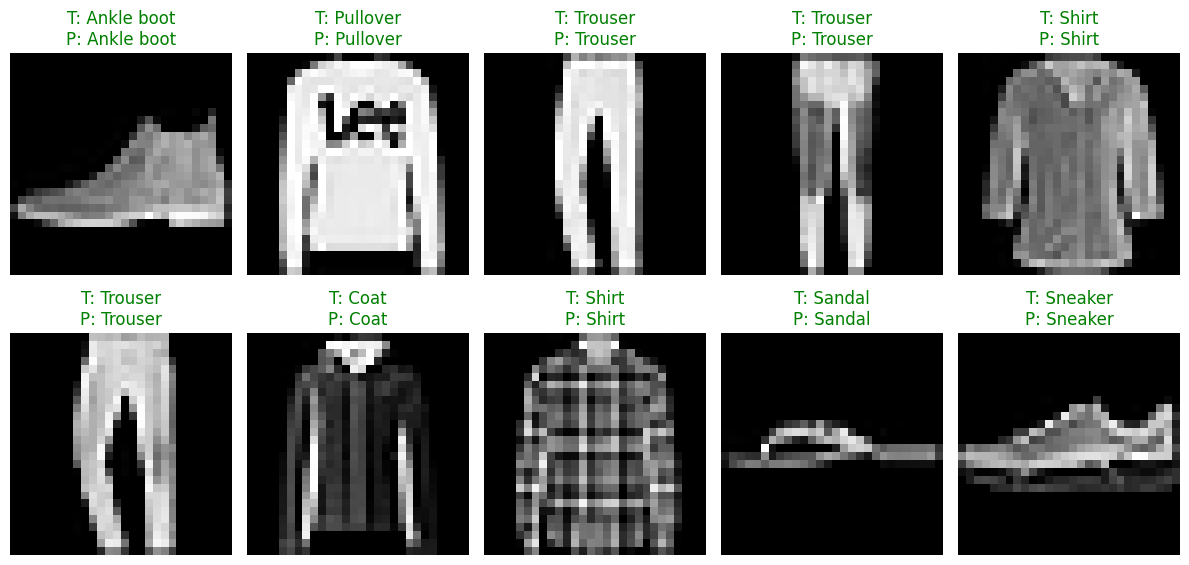

In [13]:
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap="gray")

    true_label = class_names[labels[i]]
    pred_label = class_names[preds[i]]

    color = "green" if labels[i] == preds[i] else "red"

    plt.title(f"T: {true_label}\nP: {pred_label}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

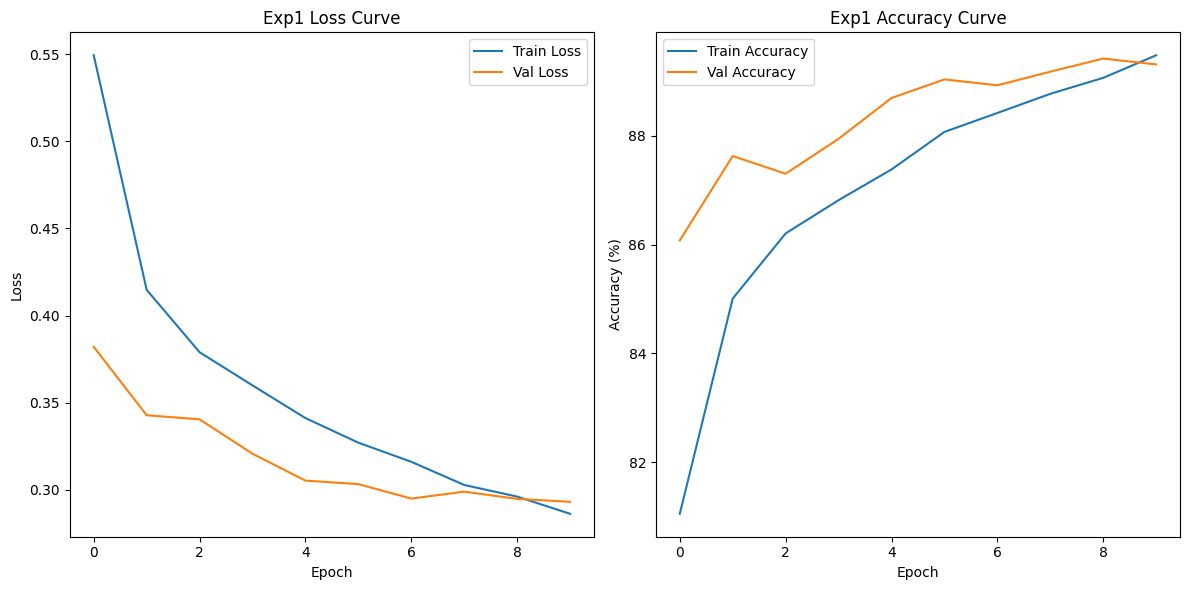

In [22]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Exp1 Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.title("Exp1 Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.tight_layout()
plt.show()

Experiment 2 (LR + Architecture Change) — Full Code
📌 1. Model (3 Hidden Layers)

In [15]:
class MLP2(nn.Module):
    def __init__(self):
        super(MLP2, self).__init__()

        self.model = nn.Sequential(
            nn.Flatten(),

            nn.Linear(28*28, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

In [16]:
model2 = MLP2().to(device)

criterion = nn.CrossEntropyLoss()
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.0001)

In [17]:
train_losses2 = []
val_losses2 = []
train_accs2 = []
val_accs2 = []

for epoch in range(10):

    #  TRAIN
    model2.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        pred = model2(x)
        loss = criterion(pred, y)

        optimizer2.zero_grad()
        loss.backward()
        optimizer2.step()

        train_loss += loss.item()

        predicted = torch.argmax(pred, dim=1)
        train_correct += (predicted == y).sum().item()
        train_total += y.size(0)

    train_loss = train_loss / len(train_loader)
    train_acc = 100 * train_correct / train_total

    # VALIDATION
    model2.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            pred = model2(x)
            loss = criterion(pred, y)

            val_loss += loss.item()

            predicted = torch.argmax(pred, dim=1)
            val_correct += (predicted == y).sum().item()
            val_total += y.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total

    train_losses2.append(train_loss)
    val_losses2.append(val_loss)
    train_accs2.append(train_acc)
    val_accs2.append(val_acc)

    print(
        f"[EXP2] Epoch {epoch} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%"
    )

[EXP2] Epoch 0 | Train Loss: 0.8222 | Train Acc: 76.17% | Val Loss: 0.4467 | Val Acc: 84.97%
[EXP2] Epoch 1 | Train Loss: 0.4734 | Train Acc: 84.37% | Val Loss: 0.3764 | Val Acc: 86.58%
[EXP2] Epoch 2 | Train Loss: 0.4126 | Train Acc: 85.94% | Val Loss: 0.3561 | Val Acc: 87.19%
[EXP2] Epoch 3 | Train Loss: 0.3779 | Train Acc: 86.72% | Val Loss: 0.3234 | Val Acc: 88.38%
[EXP2] Epoch 4 | Train Loss: 0.3552 | Train Acc: 87.36% | Val Loss: 0.3216 | Val Acc: 88.38%
[EXP2] Epoch 5 | Train Loss: 0.3380 | Train Acc: 87.91% | Val Loss: 0.3129 | Val Acc: 88.58%
[EXP2] Epoch 6 | Train Loss: 0.3203 | Train Acc: 88.62% | Val Loss: 0.3065 | Val Acc: 88.67%
[EXP2] Epoch 7 | Train Loss: 0.3066 | Train Acc: 88.95% | Val Loss: 0.3015 | Val Acc: 89.05%
[EXP2] Epoch 8 | Train Loss: 0.2990 | Train Acc: 89.22% | Val Loss: 0.2913 | Val Acc: 89.62%
[EXP2] Epoch 9 | Train Loss: 0.2906 | Train Acc: 89.39% | Val Loss: 0.2897 | Val Acc: 89.44%


In [18]:
model2.eval()

correct = 0
total = 0
test_loss = 0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)

        pred = model2(x)
        loss = criterion(pred, y)

        test_loss += loss.item()

        predicted = torch.argmax(pred, dim=1)
        correct += (predicted == y).sum().item()
        total += y.size(0)

test_loss = test_loss / len(test_loader)
test_acc = 100 * correct / total

print("FINAL TEST RESULTS (EXP 2)")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

FINAL TEST RESULTS (EXP 2)
Test Loss: 0.3203
Test Accuracy: 88.63%


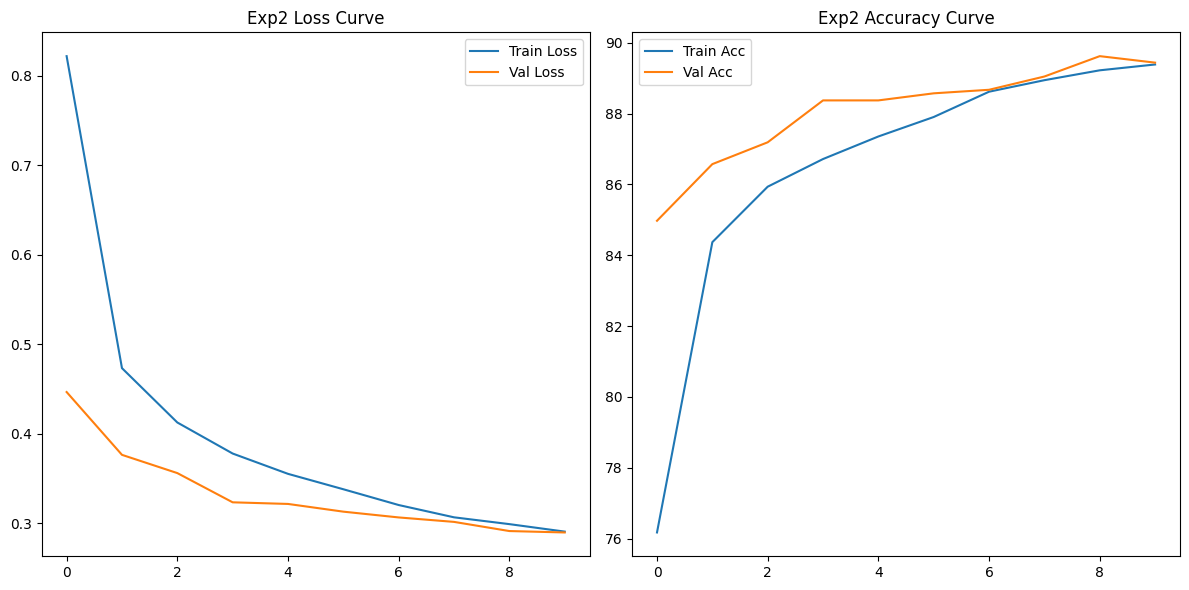

In [20]:
plt.figure(figsize=(12, 6))

# Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses2, label="Train Loss")
plt.plot(val_losses2, label="Val Loss")
plt.title("Exp2 Loss Curve")
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accs2, label="Train Acc")
plt.plot(val_accs2, label="Val Acc")
plt.title("Exp2 Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
comparison.style.format({
    "Final Train Acc (%)": "{:.2f}",
    "Final Val Acc (%)": "{:.2f}",
    "Test Acc (%)": "{:.2f}",
    "Final Train Loss": "{:.4f}",
    "Final Val Loss": "{:.4f}"
})

,Experiment,Final Train Acc (%),Final Val Acc (%),Test Acc (%),Final Train Loss,Final Val Loss
0,"Exp 1 (LR=0.001, 2 Hidden)",89.48,89.31,88.27,0.2861,0.2930
1,"Exp 2 (LR=0.0001, 3 Hidden)",89.39,89.44,88.63,0.2906,0.2897
